# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [55]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.optim import Adam
import timm
import matplotlib.pyplot as plt
import time, torch
from torch.utils.data import WeightedRandomSampler, DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from torch import amp

import sys
sys.path.append("../utils")
from utils import create_balanced_split , ISIC_Multimodal_Dataset
import evaluator

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths (adjust if needed)
DATA_DIR = Path("../data")
TRAIN_META_CSV = DATA_DIR / "train-metadata.csv"
TEST_META_CSV  = DATA_DIR / "test-metadata.csv"
TRAIN_H5_PATH  = DATA_DIR / "train-image.hdf5"
TEST_H5_PATH   = DATA_DIR / "test-image.hdf5"

# Columns
ID_COL      = "isic_id"
TARGET_COL  = "target"
GROUP_COL   = "patient_id"

RANDOM_STATE = 42
N_SPLITS = 5

print(TRAIN_META_CSV.resolve())
print(TRAIN_H5_PATH.resolve())

Using device: cuda
/home/pawn/Desktop/deep_learning/ISIC_DL/data/train-metadata.csv
/home/pawn/Desktop/deep_learning/ISIC_DL/data/train-image.hdf5


## Load and analyze the data

Because of the extreme class imbalance in the dataset (approximately 0.01 vs 99.99), we follow two strategies. First, we limit the ratio of healthy lesions included during training: instead of using the full 400,000 benign images, we use a controlled ratio of 25 benign samples per malignant sample. Second, we apply targeted data augmentation to malignant class (class 1) examples to increase their effective variability and reduce overfitting.

For class 1 (malignant lesions), we apply medically appropriate augmentations inspired by the recommendations in Mahbod et al., *"Effects of augmentation strategies on skin lesion classification"* (2019). Their study demonstrates that carefully selected geometric and photometric transformations improve melanoma classification performance while avoiding unrealistic distortions.

Below is a summary of the augmentation pipeline used in this work.

### Data Augmentation for Skin Lesion Classification (ISIC)

To improve model generalization in skin lesion classification, we apply a set of medically validated data augmentations. These transformations simulate real-world acquisition variability, including differences in camera systems, zoom levels, lighting conditions, focus, rotation, and minor occlusions such as hair or ruler marks.

A brief explanation of each augmentation follows.

1. Resize → RandomResizedCrop
Images are first resized for consistent input dimensions. A random crop (90%–100% of the area) is then extracted.
*Purpose*: Simulates variation in zoom and framing across dermoscopy systems.


2. Random Rotation (±15°)
Applies small rotations without distorting the lesion structure.
*Purpose*: Lesions do not have a fixed orientation; rotation increases representation diversity.


3. Horizontal Flip
Mirrors the image horizontally.
*Purpose*: Human anatomy is largely symmetric; lesion appearance remains valid under flipping.


4. ColorJitter
Applies light variations in brightness, contrast, saturation, and hue.
*Purpose*: Models differences across dermatoscopes, lighting conditions, and skin tones.

5. RandomAdjustSharpness
Applies slight sharpening at random.
*Purpose*: Simulates variability in optical focus and imaging quality.

6. Gaussian Blur
Adds small blur variations.
*Purpose*: Reproduces the behavior of different dermoscopic camera systems.

7. RandomErasing
Erases a small random region of the image.
*Purpose*: Simulates occlusions such as hair, bubbles, ruler artifacts, or pen marks.

8. Normalize (ImageNet mean/std)
Standard normalization used with ImageNet-pretrained CNNs.

#### Scientific Support

These augmentations are supported by dermatology-focused studies, particularly:

**Mahbod et al., "Effects of augmentation strategies on skin lesion classification" (2019)**  
This work shows that:
- light geometric transformations,  
- controlled color perturbations,  
- blur and sharpness adjustments,  
- and occlusion-based augmentations  
consistently improve melanoma classification accuracy across ISIC datasets.

Link: https://arxiv.org/abs/1910.05351

---

Together, these augmentations increase robustness, reduce overfitting, and help compensate for the limited number of malignant samples in the dataset.


In [56]:
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode


class DermoscopyAugmentation:
    """
    Scientific-grade augmentation pipeline for skin lesion classification.
    Designed based on augmentation strategies validated in ISIC Challenge papers.
    """

    @staticmethod
    def get_dataAugmentation_transforms():
        """Training augmentations (medically validated)"""
        return T.Compose([
            # --- Spatial ---
            T.Resize(256),
            T.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
            T.RandomRotation(15, interpolation=InterpolationMode.BILINEAR),
            T.RandomHorizontalFlip(p=0.5),

            # --- Photometric ---
            T.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.1,
                hue=0.02
            ),
            T.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),

        ])

    @staticmethod
    def get_preprocess_transforms():
        """Preprocess transforms (base transforms)"""
        return T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
            # --- Regularization ---
            T.RandomErasing(
                p=0.1,
                scale=(0.02, 0.07),
                ratio=(0.3, 3.0)
            )
        ])

In [57]:
# 1º Create a split of train and validation balanced
# we dont need all the images
NEG_RATIO = 30      # 25:1
train_df, val_df, df_balanced = create_balanced_split(
    TRAIN_META_CSV,
    neg_multiplier=NEG_RATIO,      # conservative ratio of 25:1 
    val_frac=0.2            # split a 20% of train to validation
)

# 2º Create the augmented test and validation datasets trasforming the data
# with the following methods

augmentation_trans = DermoscopyAugmentation.get_dataAugmentation_transforms()
preprocess_trans = DermoscopyAugmentation.get_preprocess_transforms()

train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TRAIN_H5_PATH,
    metadata_df=train_df,
    data_augmentation_trans=augmentation_trans,
    image_transform=preprocess_trans,
    augment_positives=True
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TRAIN_H5_PATH,
    metadata_df=val_df,
    image_transform=preprocess_trans,
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TEST_H5_PATH,
    metadata_df=pd.read_csv(TEST_META_CSV),
    image_transform=preprocess_trans,
)


/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:56: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 10290

Balanced dataset size: 10633
target
0    10290
1      343
Name: count, dtype: int64


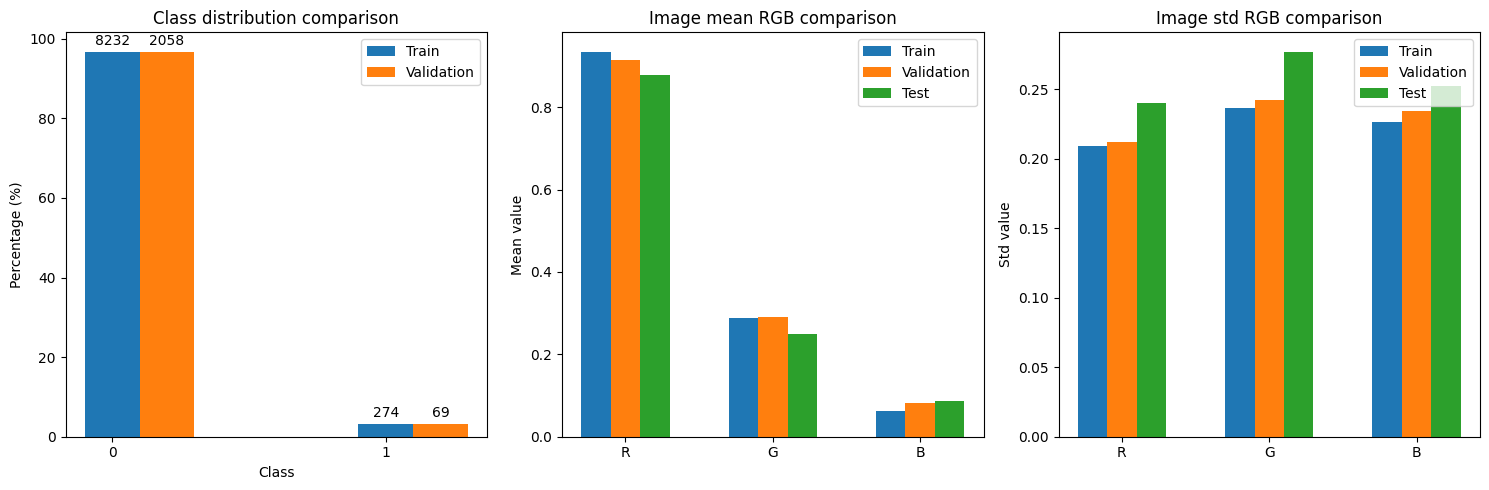

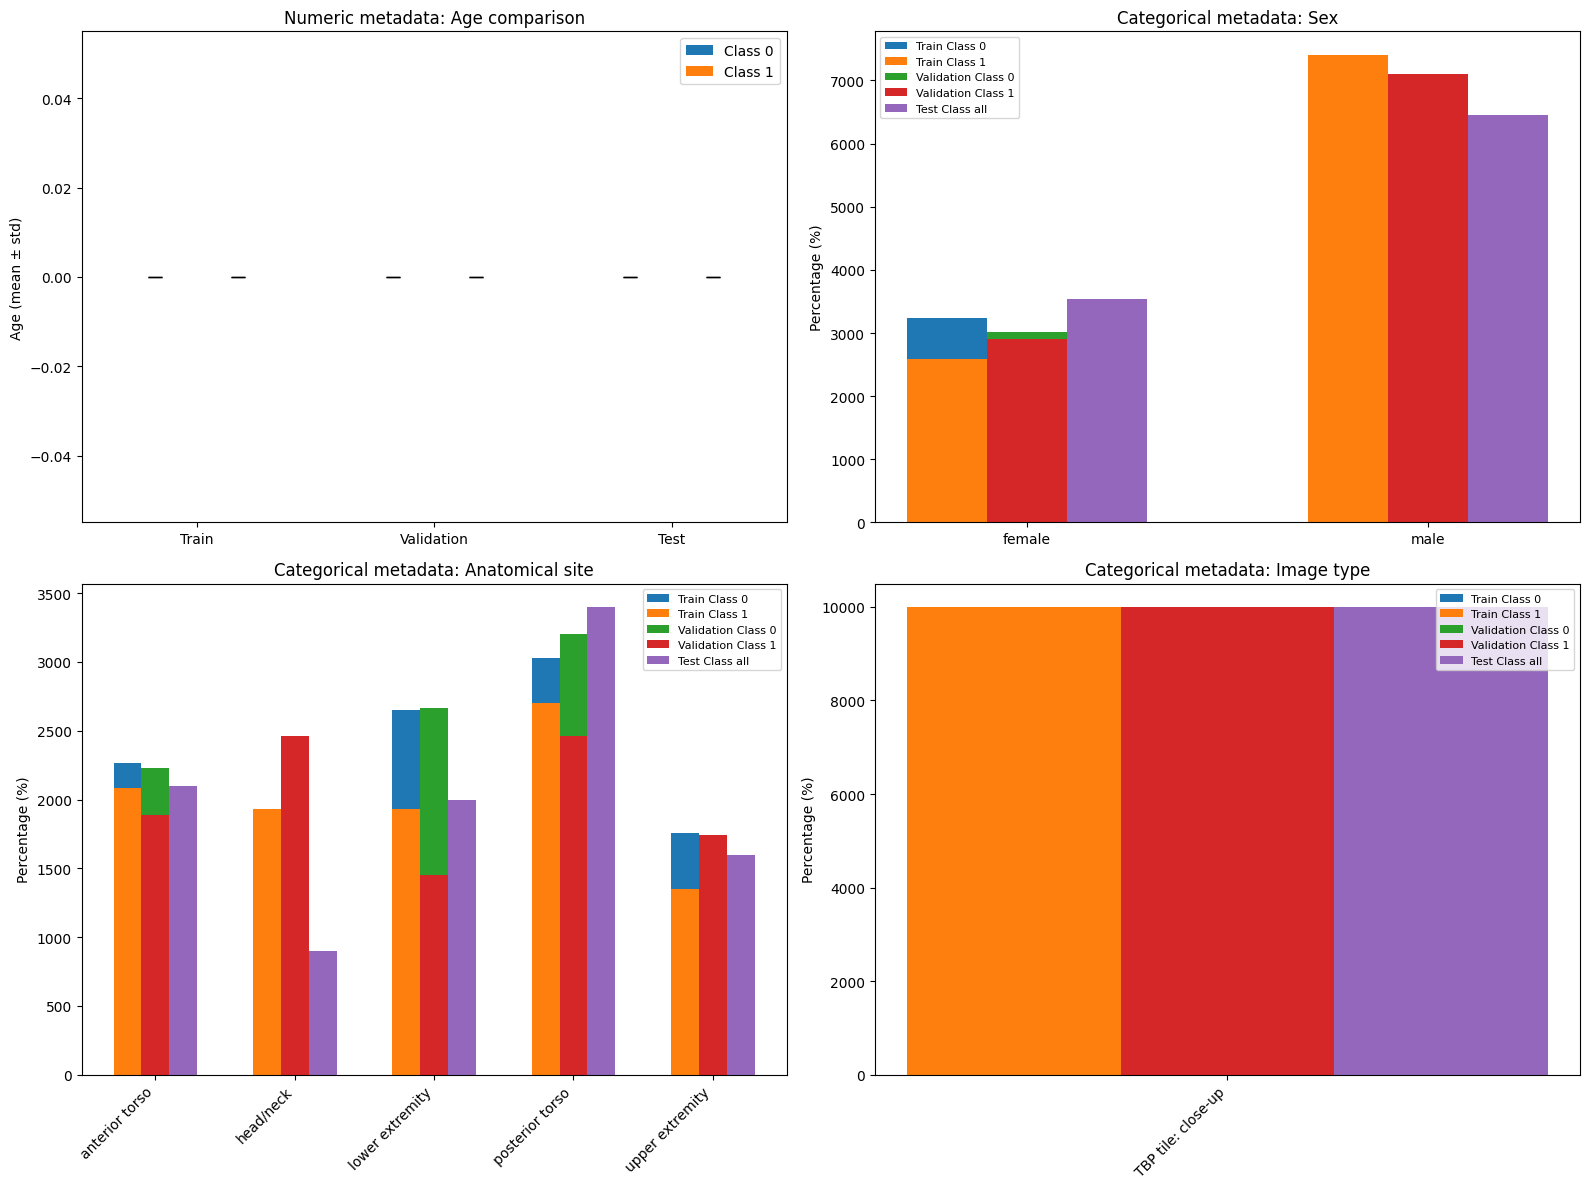

In [58]:
from utils import plot_dataset_comparison_subplots

train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# Now we compare the analisis of the splits
plot_dataset_comparison_subplots(stats_list)

## DataLoaders

In [59]:
def calculate_sample_weights(targets, class_weights):
    """Calculate weight for each sample based on its class"""
    sample_weights = np.zeros(len(targets))
    for idx, target in enumerate(targets):
        sample_weights[idx] = class_weights[int(target)]
    return sample_weights

In [60]:
from utils import PositiveOversampler
BATCH_SIZE = 64
NUM_POS_RATIO = 3   # ratio of sampling new data

y_train = train_df['target'].values
class_weights = np.array([1.0, NEG_RATIO])  # [benign, malignant]

# Convert to PyTorch tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# Calculate sample weights for balanced training
multimodal_train_targets = train_dataset.metadata['target'].values
multimodal_sample_weights = calculate_sample_weights(multimodal_train_targets, class_weights)

multimodal_weighted_sampler = WeightedRandomSampler(
    weights=multimodal_sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

pos_oversampler = PositiveOversampler(train_dataset, pos_multiplier=4)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=pos_oversampler,    # multimodal_weighted_sampler,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")


📦 Multimodal data loaders created with balanced sampling!


In [61]:
# Create weighted loss function with conservative pos_weight
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(NEG_RATIO).to(device))


# Backbone

In [62]:
class MetadataMLP(nn.Module):
    def __init__(self, in_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(0.2),

            nn.Linear(hidden, hidden//2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden//2),
            nn.Dropout(0.2),
        )
        self.out_dim = hidden//2

    def forward(self, x):
        return self.net(x)


class PretrainedClassifier(nn.Module):
    def __init__(self, model_name, metadata_dim, num_classes=1, pretrained=True):
        super().__init__()
        
        # Backbone for the image
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0  # quitamos la cabeza original
        )

        # Dummy input to get the real dimension of backbone output
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224)  # ajustar tamaño según tu input
            img_feat = self.backbone(dummy_img)
        
        # MLP for the metadata
        self.meta_mlp = MetadataMLP(metadata_dim)
        
        # Mix both process
        fusion_dim = img_feat.shape[1] + self.meta_mlp.out_dim
        
        # Final head combining both data
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, meta):
        # Image processed by Backbone
        img_feat = self.backbone(image)

        # Metadata processed by MLP
        meta_feat = self.meta_mlp(meta)
        # mix and pass to the head
        fused = torch.cat([img_feat, meta_feat], dim=1)
        out = self.head(fused)
        return out

class EnsembleClassifier(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = nn.ModuleList(models)

    def forward(self, image, metadata=None):
        outputs = [model(image, metadata) for model in self.models]
        avg_output = torch.mean(torch.stack(outputs), dim=0)
        return avg_output

### Now we wrap the ensemble with a train function

In [63]:
class EnsembleClassifierExtended(EnsembleClassifier):
    def __init__(self, models, criterion, device=device,
                 patience=5, min_delta=0.0):
        super().__init__(models)

        self.device = device
        self.criterion = criterion
        self.optimizer = Adam(self.parameters(), lr=1e-4)
        self.to(device)

        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

        # Early stopping
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False
        self.best_state_dict = None

        # Mixed Precision auto-scaler
        if self.device.type == "cuda":
            self.scaler = amp.GradScaler()
        else:
            self.scaler = None

    def fit(self, train_loader, val_loader=None, epochs=10):

        for epoch in range(1, epochs+1):
            torch.cuda.synchronize()
            start = time.time()
            print(f"\nEpoch {epoch}/{epochs}: ", end="")

            train_loss = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"\tTrain loss: {train_loss:.4f}", end="")

            if val_loader:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"\tVal Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")

    # -------------------------------------------------------------
    def _train_epoch(self, loader):
        self.train()
        total_loss = 0

        for images, metadata, labels in tqdm(loader, leave=False):
            images = images.to(self.device, non_blocking=True)
            metadata = metadata.to(self.device, non_blocking=True)
            labels = labels.float().to(self.device, non_blocking=True)

            self.optimizer.zero_grad()

            with amp.autocast(device_type=self.device.type):  # AMP
                preds = self(images, metadata).squeeze()
                loss = self.criterion(preds, labels)

            # AMP scaled backward
            if self.scaler is not None:
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss.backward()
                self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(loader)

    # -------------------------------------------------------------
    def _validate(self, loader):
        self.eval()
        total_loss = 0
        preds_list = []
        labels_list = []

        with torch.no_grad():
            for images, metadata, labels in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)
                labels = labels.float().to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP también en eval
                    preds = self(images, metadata).squeeze()
                    loss = self.criterion(preds, labels)

                total_loss += loss.item()

                preds_list.append(preds.float().cpu())
                labels_list.append(labels.cpu())

        preds = torch.cat(preds_list).sigmoid().numpy()
        labels = torch.cat(labels_list).numpy()

        auc = roc_auc_score(labels, preds)

        return total_loss / len(loader), auc

    # -------------------------------------------------------------
    def _check_early_stopping(self, score):

        if self.best_score is None:
            self.best_score = score
            self.best_state_dict = self.state_dict()
            return False

        # Check if we improve the results over the last epoch and some margin
        if score >= self.best_score + self.min_delta:
            self.best_score = score
            self.best_state_dict = self.state_dict()
            self.counter = 0
        else:
            self.counter += 1

            # if we dont improve in n epoch we get out            
            if self.counter >= self.patience:
                return True

        return False
    

    # -------------------------------------------------------------
    def predict_proba(self, loader):
        self.eval()
        probs = []

        with torch.no_grad():
            for images, metadata, _ in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):
                    p = self(images, metadata).sigmoid().squeeze()
                probs.append(p.cpu().numpy())

        return np.concatenate(probs)

    def predict(self, loader, threshold=0.5):
        return (self.predict_proba(loader) >= threshold).astype(int)

    # -------------------------------------------------------------
    def save(self, path):
        torch.save(self.state_dict(), path)

    def load(self, path):
        self.load_state_dict(torch.load(path, map_location=self.device))
        self.to(self.device)


# Train

In [64]:
# now we create the models for the train
num_metadata_features = train_dataset.metadata_features.shape[1]

#-------------------------------------------------------------------------------
# 1º Define the models of the ensemble
#-------------------------------------------------------------------------------
model1 = PretrainedClassifier("resnet18", metadata_dim=num_metadata_features)
model2 = PretrainedClassifier("mobilenetv3_small_100", metadata_dim=num_metadata_features)
model3 = PretrainedClassifier("efficientnet_b0", metadata_dim=num_metadata_features)

model_list = [model1, model2, model3]

#-------------------------------------------------------------------------------
# 2º Define the parámeters and the enseble 
#-------------------------------------------------------------------------------
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(NEG_RATIO).to(device))

ensemble_class = EnsembleClassifierExtended(
                    models=model_list, 
                    criterion=criterion,
                    device=device, 
                    min_delta=1e-4).to(device)
ensemble_class.fit(train_loader, val_loader=valid_loader, epochs=25)


Epoch 1/25: 

	Train loss: 1.2358

	Val Loss: 0.7468 | AUC: 0.9290 in 54.78s

Epoch 2/25: 

	Train loss: 0.5162

	Val Loss: 0.7097 | AUC: 0.9294 in 49.46s

Epoch 3/25: 

...

	Val Loss: 1.5020 | AUC: 0.8962 in 50.51s

Epoch 20/25: 

	Train loss: 0.0396

	Val Loss: 1.6008 | AUC: 0.9032 in 50.30s

Epoch 21/25: 

	Train loss: 0.0701

	Val Loss: 1.2845 | AUC: 0.9067

### Plot the results of the train

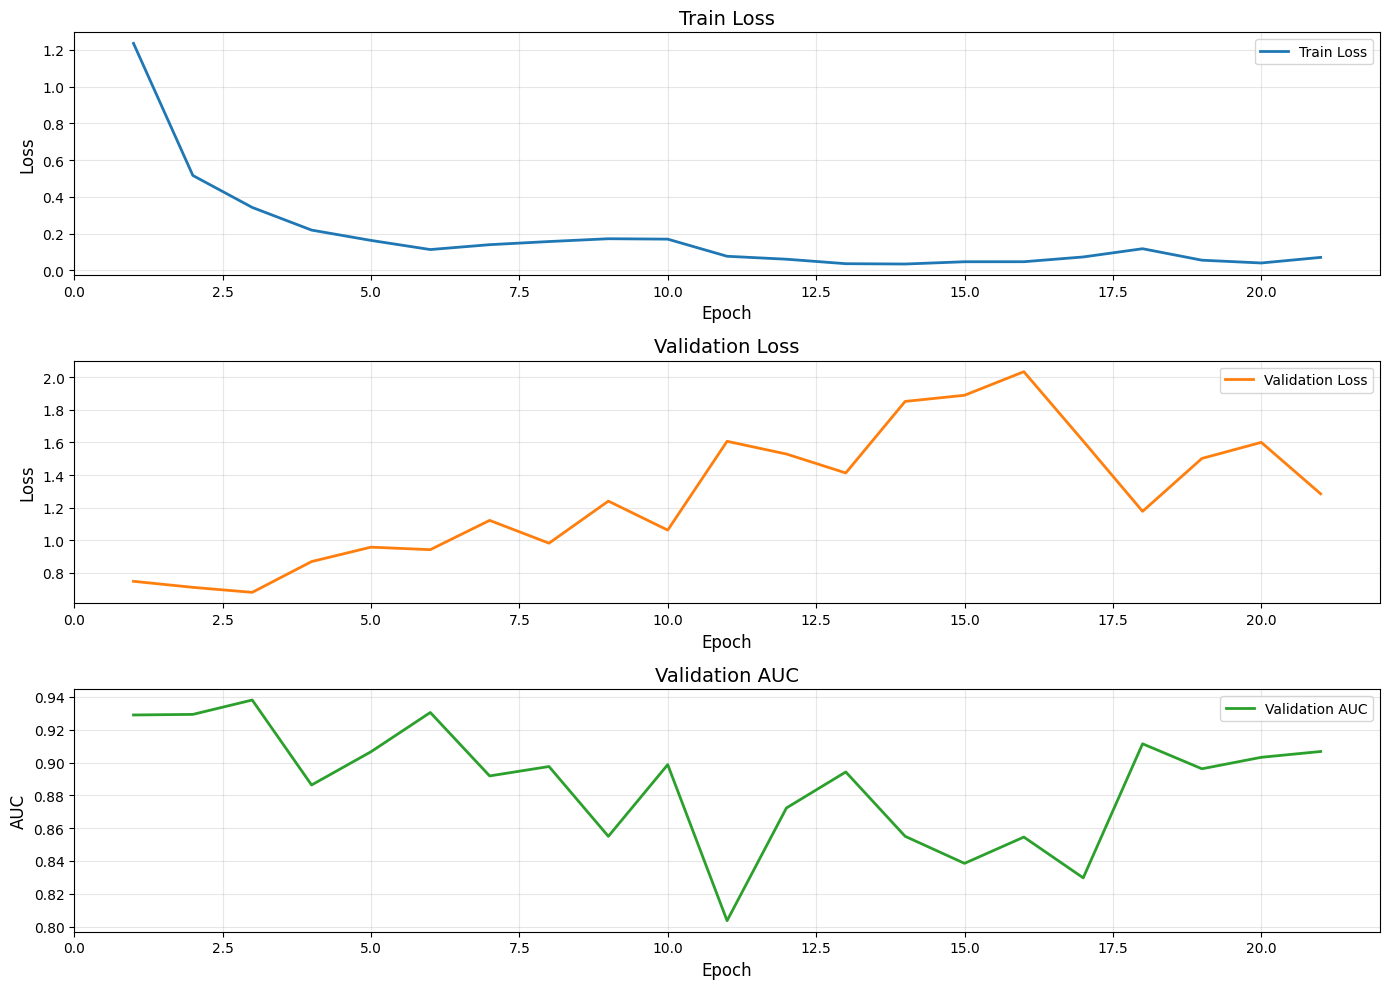

In [65]:

train_loss = ensemble_class.history["train_loss"]
val_loss = ensemble_class.history["val_loss"]
val_auc = ensemble_class.history["val_auc"]

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14, 10))

# 1. TRAIN LOSS
plt.subplot(3, 1, 1)
plt.plot(epochs, train_loss, label="Train Loss", color="tab:blue", linewidth=2)
plt.title("Train Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 2. VALIDATION LOSS
plt.subplot(3, 1, 2)
plt.plot(epochs, val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
plt.title("Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 3. VALIDATION AUC
plt.subplot(3, 1, 3)
plt.plot(epochs, val_auc, label="Validation AUC", color="tab:green", linewidth=2)
plt.title("Validation AUC", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# Ajustar los subplots para que no se solapen
plt.tight_layout()
plt.show()